# 02. Data Preprocessing & Feature Engineering

**Objective:** Clean the raw `application_train.csv`, engineer features, handle missing values, encode categoricals, scale numerics, handle class imbalance, and produce train/val/test splits ready for all four models.

**Pipeline outputs:**
- `data/processed/X_train.csv`, `X_val.csv`, `X_test.csv`
- `data/processed/y_train.csv`, `y_val.csv`, `y_test.csv`
- `data/processed/X_train_smote.csv`, `y_train_smote.csv` (SMOTE-resampled)
- `data/processed/preprocessor.pkl` (fitted sklearn Pipeline)

**Model-specific notes:**
| Step | Logistic Regression (baseline & elastic net) | Random Forest | MLP |
|---|---|---|---|
| StandardScaler | Required | Not needed but harmless | Required |
| One-hot encoding | Required | Required | Required |
| log1p on monetary | Recommended | Not needed | Recommended |
| SMOTE | Compare with/without | Compare with/without | Compare with/without |
| Missing indicators | Useful for linear models | Handled natively | Useful |

## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)

# mount drive
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR   = "/content/drive/MyDrive/MLDL/loan-default-project/01_data/01_raw"
# OUT_DIR    = "/content/drive/MyDrive/MLDL/loan-default-project/01_data/02_processed"
OUT_DIR    = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed"
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


## 1. Load raw data

In [ ]:
df = pd.read_csv(f"{DATA_DIR}/application_train.csv")
print(f"Raw shape: {df.shape}")
print(f"Target distribution:\n{df['TARGET'].value_counts(normalize=True).round(4)}")

Raw shape: (307511, 122)
Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


## 2. Row-level cleaning

Drop 6 rows with `XNA` / `Unknown` in small-cardinality categoricals (confirmed in EDA section 5).
These are not imputable, they are genuinely ambiguous entries.

In [ ]:
before = len(df)

# CODE_GENDER has 4 XNA rows; NAME_FAMILY_STATUS has 2 Unknown rows
df = df[df['CODE_GENDER'] != 'XNA']
df = df[df['NAME_FAMILY_STATUS'] != 'Unknown']

df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} ambiguous rows. New shape: {df.shape}")

Dropped 6 ambiguous rows. New shape: (307505, 122)


## 3. Feature Engineering (pre-split)

Engineer features that use the raw columns **before** we drop those columns or split the data.
All engineered features are domain-motivated ratios from the EDA (section 6.4 pairplots confirmed
the structural relationships these ratios capture).

In [ ]:
# --- 3.1 DAYS_EMPLOYED sentinel fix ---
# 365243 is a fake value for unemployed applicants. Replace with NaN and add a binary flag.
# The flag itself becomes a feature: 1 = unemployed/no current job, 0 = employed.
# Must happen BEFORE any imputation so the imputer sees NaN and fills with the median.
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"DAYS_EMPLOYED_ANOM flag: {df['DAYS_EMPLOYED_ANOM'].sum():,} unemployed applicants flagged")

# --- 3.2 Age in years (from DAYS_BIRTH) ---
# DAYS_BIRTH is negative days. Convert to positive years so it is interpretable
# in the fairness analysis and coefficient tables.
df['age_years'] = -df['DAYS_BIRTH'] / 365.25

# --- 3.3 Flip sign on remaining DAYS_* columns ---
# Negative days are not wrong but confusing. Flip to positive so "more days = longer ago".
for col in ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    df[col] = -df[col]

# DAYS_EMPLOYED is already NaN for unemployed; flip sign for the real values
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: -x if pd.notna(x) and x < 0 else x)

# --- 3.4 Engineered ratio features ---
# Ratios derived from the four monetary columns. These capture relationships
# that raw columns cannot: a 500k loan is very different risk for someone
# earning 30k vs 300k.
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TERM']          = df['AMT_CREDIT']  / df['AMT_ANNUITY']        # effective loan months
df['CREDIT_GOODS_RATIO']   = df['AMT_CREDIT']  / df['AMT_GOODS_PRICE']   # loan-to-goods (>1 = fees funded)

# All four ratios can produce inf when denominator is 0; replace with NaN for safe imputation
for col in ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'CREDIT_GOODS_RATIO']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

print("\nEngineered features created:")
print("  DAYS_EMPLOYED_ANOM, age_years")
print("  CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM, CREDIT_GOODS_RATIO")
print(f"\nDataset shape after feature engineering: {df.shape}")

DAYS_EMPLOYED_ANOM flag: 55,374 unemployed applicants flagged

Engineered features created:
  DAYS_EMPLOYED_ANOM, age_years
  CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM, CREDIT_GOODS_RATIO

Dataset shape after feature engineering: (307505, 128)


## 4. Drop columns

49 columns identified in EDA section 10 (preprocessing to-do) are dropped:
- `SK_ID_CURR`: identifier, not a feature
- `DAYS_BIRTH`: replaced by `age_years`
- Zero-variance flags (`FLAG_MOBIL`, `FLAG_CONT_MOBILE`)
- Near-duplicate (`REGION_RATING_CLIENT_W_CITY` = 0.95 corr with `REGION_RATING_CLIENT`)
- `OWN_CAR_AGE`: 66% missing, redundant with `FLAG_OWN_CAR`
- Entire G1 building-features block (~50% missing, ~0 correlation with TARGET)
- Rare `FLAG_DOCUMENT_*` columns with < 1% positive rate

In [ ]:
COLS_TO_DROP = [
    # identifier
    'SK_ID_CURR',
    # replaced by age_years
    'DAYS_BIRTH',
    # zero-variance binary flags
    'FLAG_MOBIL', 'FLAG_CONT_MOBILE',
    # near-duplicate of REGION_RATING_CLIENT
    'REGION_RATING_CLIENT_W_CITY',
    # high missingness, redundant with FLAG_OWN_CAR
    'OWN_CAR_AGE',
    # G1 building-features block (all _AVG, _MEDI, _MODE variants)
    'APARTMENTS_AVG','APARTMENTS_MEDI','APARTMENTS_MODE',
    'BASEMENTAREA_AVG','BASEMENTAREA_MEDI','BASEMENTAREA_MODE',
    'YEARS_BEGINEXPLUATATION_AVG','YEARS_BEGINEXPLUATATION_MEDI','YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_AVG','YEARS_BUILD_MEDI','YEARS_BUILD_MODE',
    'COMMONAREA_AVG','COMMONAREA_MEDI','COMMONAREA_MODE',
    'ELEVATORS_AVG','ELEVATORS_MEDI','ELEVATORS_MODE',
    'ENTRANCES_AVG','ENTRANCES_MEDI','ENTRANCES_MODE',
    'FLOORSMAX_AVG','FLOORSMAX_MEDI','FLOORSMAX_MODE',
    'FLOORSMIN_AVG','FLOORSMIN_MEDI','FLOORSMIN_MODE',
    'LANDAREA_AVG','LANDAREA_MEDI','LANDAREA_MODE',
    'LIVINGAPARTMENTS_AVG','LIVINGAPARTMENTS_MEDI','LIVINGAPARTMENTS_MODE',
    'LIVINGAREA_AVG','LIVINGAREA_MEDI','LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_MEDI','NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAREA_AVG','NONLIVINGAREA_MEDI','NONLIVINGAREA_MODE',
    'FONDKAPREMONT_MODE','HOUSETYPE_MODE','TOTALAREA_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE',
    # near-zero variance rare document flags
    'FLAG_DOCUMENT_2','FLAG_DOCUMENT_4','FLAG_DOCUMENT_7','FLAG_DOCUMENT_9','FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_12','FLAG_DOCUMENT_13','FLAG_DOCUMENT_14','FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_17','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21',
]

# only drop what actually exists in the dataframe (defensive)
existing_drops = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=existing_drops, inplace=True)

print(f"Dropped {len(existing_drops)} columns.")
print(f"Dataset shape after drops: {df.shape}")

Dropped 66 columns.
Dataset shape after drops: (307505, 62)


## 5. Hard-cap single-point outliers

These columns are mostly well-behaved counts with one or two extreme values that are almost
certainly data-entry errors. We cap at a hard threshold rather than a percentile because
99% of values are already clean. See EDA section 8.1 for the IQR evidence.

In [ ]:
# Hard caps: threshold chosen from EDA (anything above is implausible)
HARD_CAPS = {
    'CNT_CHILDREN':              10,   # max observed 19, plausible max ~10
    'CNT_FAM_MEMBERS':           10,   # max observed 20, plausible max ~10
    'OBS_30_CNT_SOCIAL_CIRCLE':  30,   # max observed 348, typical <5
    'OBS_60_CNT_SOCIAL_CIRCLE':  30,   # max observed 344, typical <5
    'AMT_REQ_CREDIT_BUREAU_QRT': 20,   # max observed 261, typical 0
}

for col, cap in HARD_CAPS.items():
    if col in df.columns:
        n_capped = (df[col] > cap).sum()
        df[col] = df[col].clip(upper=cap)
        print(f"  {col}: capped {n_capped} values at {cap}")

  CNT_CHILDREN: capped 8 values at 10
  CNT_FAM_MEMBERS: capped 11 values at 10
  OBS_30_CNT_SOCIAL_CIRCLE: capped 2 values at 30
  OBS_60_CNT_SOCIAL_CIRCLE: capped 2 values at 30
  AMT_REQ_CREDIT_BUREAU_QRT: capped 1 values at 20


## 6. Train / Validation / Test split

**Important:** We split BEFORE fitting any imputer/scaler to prevent data leakage.
All transformers are fitted on X_train only and applied to val/test.

Split: 70% train / 15% val / 15% test, stratified on TARGET.

In [ ]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

# First cut off 30% (val+test), then split that 50/50
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:  {X_train.shape}  | default rate: {y_train.mean():.4f}")
print(f"Val:    {X_val.shape}   | default rate: {y_val.mean():.4f}")
print(f"Test:   {X_test.shape}  | default rate: {y_test.mean():.4f}")

Train:  (215253, 61)  | default rate: 0.0807
Val:    (46126, 61)   | default rate: 0.0807
Test:   (46126, 61)  | default rate: 0.0807


## 7. Define column groups for the pipeline

We route columns to different transformers in the ColumnTransformer based on their type
and the preprocessing decision documented in EDA section 10.

In [ ]:
# --- 7.1 Ordinal encode: education (natural order confirmed in EDA section 6.1) ---
EDUCATION_ORDER = [
    ['Lower secondary', 'Secondary / secondary special',
     'Incomplete higher', 'Higher education', 'Academic degree']
]
ordinal_cols = ['NAME_EDUCATION_TYPE']

# --- 7.2 One-hot encode: standard low-cardinality categoricals ---
# OCCUPATION_TYPE and NAME_TYPE_SUITE will have 'Missing' imputed before OHE
onehot_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
    'OCCUPATION_TYPE',
]
onehot_cols = [c for c in onehot_cols if c in X_train.columns]

# --- 7.3 Monetary columns: log1p transform then scale ---
# log1p normalises heavy right tails before StandardScaler.
# Helps logistic regression and MLP; Tree models are invariant (harmless).
monetary_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
monetary_cols = [c for c in monetary_cols if c in X_train.columns]

# --- 7.4 EXT_SOURCE columns: impute + add missingness flag + scale ---
# These are the top predictors; missingness is informative (EDA section 9).
# We add the missingness flags manually before the pipeline.
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_source_cols = [c for c in ext_source_cols if c in X_train.columns]

# Add missingness flags to train/val/test NOW (before pipeline, so the flags go through
# passthrough as binary numeric cols)
for split_X in [X_train, X_val, X_test]:
    for col in ext_source_cols:
        split_X[f'{col}_MISSING'] = split_X[col].isna().astype(int)

ext_missing_flags = [f'{c}_MISSING' for c in ext_source_cols]

# --- 7.5 All remaining numeric columns: impute median + scale ---
all_cat = set(ordinal_cols + onehot_cols)
all_special_numeric = set(
    monetary_cols + ext_source_cols + ext_missing_flags
    + ['DAYS_EMPLOYED_ANOM']  # already 0/1, no scaling needed but harmless
)

numeric_rest = [
    c for c in X_train.columns
    if c not in all_cat and c not in all_special_numeric
    and X_train[c].dtype in [np.float64, np.int64, np.float32, np.int32, 'float64', 'int64']
]

print(f"ordinal_cols:       {ordinal_cols}")
print(f"onehot_cols ({len(onehot_cols)}):   {onehot_cols}")
print(f"monetary_cols:      {monetary_cols}")
print(f"ext_source_cols:    {ext_source_cols}")
print(f"ext_missing_flags:  {ext_missing_flags}")
print(f"numeric_rest ({len(numeric_rest)}):  {numeric_rest[:10]} ...")

ordinal_cols:       ['NAME_EDUCATION_TYPE']
onehot_cols (11):   ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'OCCUPATION_TYPE']
monetary_cols:      ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
ext_source_cols:    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_missing_flags:  ['EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']
numeric_rest (41):  ['CNT_CHILDREN', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS'] ...


## 8. Impute semantic categoricals before the pipeline

`OCCUPATION_TYPE` (31% missing) and `NAME_TYPE_SUITE` (0.4% missing): missingness is
semantically meaningful (no occupation = pensioner/unemployed; no companion = came alone).
Fill with literal string `'Missing'` rather than collapsing to mode. This preserves the
signal as its own OHE column.

> Fit only on training data to avoid leakage, but since we are using a fixed string
> (not the training mode), this step is leak-free and can be applied to all splits.

In [ ]:
SEMANTIC_NAN_COLS = ['OCCUPATION_TYPE', 'NAME_TYPE_SUITE']

for col in SEMANTIC_NAN_COLS:
    for split_X in [X_train, X_val, X_test]:
        if col in split_X.columns:
            split_X[col] = split_X[col].fillna('Missing')

print("Semantic NaN columns filled with 'Missing'.")

Semantic NaN columns filled with 'Missing'.


## 9. Rare-category grouping for high-cardinality categoricals

Categories that appear in <1% of the TRAINING set get collapsed to `'Other'`.
Threshold fitted on training set only; same mapping applied to val/test.

> **Why?** `ORGANIZATION_TYPE` has 58 levels. One-hot without grouping produces 58 sparse columns
> where most cells are 0, this hurts logistic regression and increases dimensionality for the MLP.

In [ ]:
RARE_THRESHOLD = 0.01  # categories below 1% of training set -> 'Other'
HIGH_CARD_COLS = ['ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE']

# Categories to always keep regardless of frequency: they carry strong default signal
# (EDA section 6.1: Maternity leave ~40% default rate, Unemployed ~36% default rate)
PROTECTED_CATS = {
    'NAME_INCOME_TYPE': ['Maternity leave', 'Unemployed'],
}

rare_map = {}  # store mapping so we can apply to val/test

for col in HIGH_CARD_COLS:
    if col not in X_train.columns:
        continue
    freq = X_train[col].value_counts(normalize=True)
    protected = PROTECTED_CATS.get(col, [])
    rare_cats = freq[(freq < RARE_THRESHOLD) & (~freq.index.isin(protected))].index.tolist()
    rare_map[col] = rare_cats

    for split_X in [X_train, X_val, X_test]:
        split_X[col] = split_X[col].apply(
            lambda v: 'Other' if v in rare_cats else v
        )

    n_orig = len(freq)
    n_after = X_train[col].nunique()
    print(f"  {col}: {n_orig} -> {n_after} categories ({len(rare_cats)} grouped into 'Other')")
    if protected:
        print(f"    [protected from grouping: {protected}]")

  ORGANIZATION_TYPE: 58 -> 17 categories (41 grouped into 'Other')
  NAME_INCOME_TYPE: 8 -> 7 categories (2 grouped into 'Other')
    [protected from grouping: ['Maternity leave', 'Unemployed']]
  OCCUPATION_TYPE: 19 -> 13 categories (7 grouped into 'Other')


## 10. Build the sklearn ColumnTransformer + Pipeline

All numeric transforms (imputation, winsorization, scaling) go through the pipeline.
Fitted on X_train only; applied identically to X_val and X_test.

**Winsorization** (99th percentile cap) for monetary columns is implemented as a
`FunctionTransformer` that clips using quantiles computed on the training set.

In [ ]:
# --- Winsorize + log1p + scale pipeline for monetary columns ---
# We need to compute 99th percentile on training data only.
# We do this manually then bake the caps into a FunctionTransformer.

WINSOR_QUANTILE = 0.99
winsor_caps = {col: X_train[col].quantile(WINSOR_QUANTILE) for col in monetary_cols}
print("99th percentile caps for monetary columns:")
for col, cap in winsor_caps.items():
    print(f"  {col}: {cap:,.0f}")

def winsorize_monetary(X, caps=winsor_caps, cols=monetary_cols):
    """Clip each monetary column at its pre-computed 99th pct cap."""
    X = X.copy()
    for i, col in enumerate(cols):
        X[:, i] = np.clip(X[:, i], a_min=None, a_max=caps[col])
    return X

def log1p_transform(X):
    return np.log1p(np.abs(X))  # log1p after clipping, all values are >= 0

99th percentile caps for monetary columns:
  AMT_INCOME_TOTAL: 495,000
  AMT_CREDIT: 1,867,074
  AMT_ANNUITY: 69,912
  AMT_GOODS_PRICE: 1,800,000


In [ ]:
# Monetary pipeline: impute -> winsorize -> log1p -> scale
monetary_pipeline = Pipeline([
    ('impute',    SimpleImputer(strategy='median')),
    ('winsorize', FunctionTransformer(winsorize_monetary, validate=False, feature_names_out='one-to-one')),
    ('log1p',     FunctionTransformer(log1p_transform, validate=False, feature_names_out='one-to-one')),
    ('scale',     StandardScaler()),
])

# EXT_SOURCE pipeline: impute median -> scale
ext_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# Standard numeric pipeline: impute median -> scale
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

# Ordinal education: impute mode (in case of unseen) -> ordinal encode
ordinal_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='most_frequent')),
    ('encode',  OrdinalEncoder(
        categories=EDUCATION_ORDER,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

# One-hot pipeline: impute mode -> OHE
onehot_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first',          # drop first level to avoid dummy trap in logistic regression
    )),
])

# Binary / passthrough columns (missingness flags, DAYS_EMPLOYED_ANOM)
# REGION_RATING_CLIENT is intentionally excluded here - it falls into numeric_rest
# and is scaled by numeric_pipeline. Including it here would create a duplicate column.
passthrough_cols = ext_missing_flags + ['DAYS_EMPLOYED_ANOM']
passthrough_cols = [c for c in passthrough_cols if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('monetary', monetary_pipeline,  monetary_cols),
        ('ext_src',  ext_pipeline,       ext_source_cols),
        ('ordinal',  ordinal_pipeline,   ordinal_cols),
        ('onehot',   onehot_pipeline,    onehot_cols),
        ('numeric',  numeric_pipeline,   numeric_rest),
        ('passthru', 'passthrough',      passthrough_cols),
    ],
    remainder='drop',  # any column not listed above is dropped (shouldn't be any)
    verbose_feature_names_out=False,
)

print("ColumnTransformer defined.")

ColumnTransformer defined.


## 11. Fit preprocessor on training set, transform all splits

**Critical leakage prevention:** `fit_transform` on X_train, then `transform` only on X_val/X_test.

In [ ]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

# Recover feature names for interpretability (coefficients, importance charts)
feature_names = preprocessor.get_feature_names_out()

print(f"X_train_proc shape: {X_train_proc.shape}")
print(f"X_val_proc shape:   {X_val_proc.shape}")
print(f"X_test_proc shape:  {X_test_proc.shape}")
print(f"Total features:     {len(feature_names)}")

X_train_proc shape: (215253, 113)
X_val_proc shape:   (46126, 113)
X_test_proc shape:  (46126, 113)
Total features:     113


## 12. Check preprocessed data quality

In [ ]:
train_df_proc = pd.DataFrame(X_train_proc, columns=feature_names)

# Check for any remaining nulls
null_count = train_df_proc.isna().sum().sum()
print(f"Remaining NaN in X_train_proc: {null_count}")

# Check for infinite values
inf_count = np.isinf(X_train_proc).sum()
print(f"Remaining Inf in X_train_proc: {inf_count}")

# Feature summary
print(f"\nFeature value ranges (should be roughly standardised):")
print(train_df_proc.describe().loc[['mean', 'std', 'min', 'max']].round(3).T.head(20))

Remaining NaN in X_train_proc: 0
Remaining Inf in X_train_proc: 0

Feature value ranges (should be roughly standardised):
                                     mean    std    min    max
AMT_INCOME_TOTAL                    0.000  1.000 -3.654  2.512
AMT_CREDIT                          0.000  1.000 -3.309  1.923
AMT_ANNUITY                        -0.000  1.000 -4.957  2.013
AMT_GOODS_PRICE                    -0.000  1.000 -3.153  2.022
EXT_SOURCE_1                        0.000  1.000 -3.517  3.295
EXT_SOURCE_2                        0.000  1.000 -2.700  1.786
EXT_SOURCE_3                       -0.000  1.000 -2.949  2.176
NAME_EDUCATION_TYPE                 1.509  0.874  0.000  4.000
NAME_CONTRACT_TYPE_Revolving loans  0.095  0.293  0.000  1.000
CODE_GENDER_M                       0.342  0.474  0.000  1.000
FLAG_OWN_CAR_Y                      0.339  0.473  0.000  1.000
FLAG_OWN_REALTY_Y                   0.694  0.461  0.000  1.000
NAME_TYPE_SUITE_Family              0.131  0.337  0.000  1.

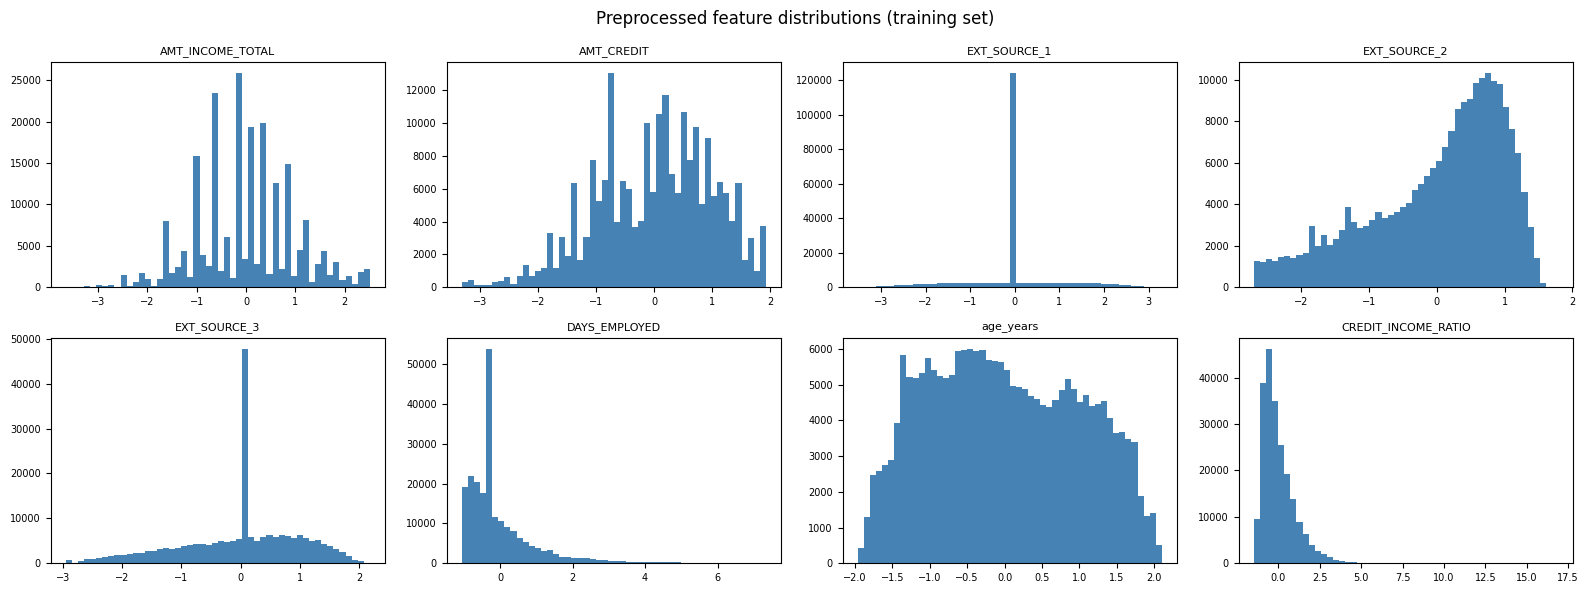

In [ ]:
# Visual sanity check: distribution of a few key features after preprocessing
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

check_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_EMPLOYED', 'age_years', 'CREDIT_INCOME_RATIO'
]

for i, feat in enumerate(check_features):
    if feat in feature_names:
        idx = list(feature_names).index(feat)
        axes[i].hist(X_train_proc[:, idx], bins=50, color='steelblue', edgecolor='none')
        axes[i].set_title(feat, fontsize=8)
        axes[i].tick_params(labelsize=7)
    else:
        axes[i].set_visible(False)

plt.suptitle("Preprocessed feature distributions (training set)")
plt.tight_layout()
plt.show()

## 13. SMOTE - class imbalance handling

**Why SMOTE?** Training set has ~8% default rate. Models trained on severely imbalanced data
tend to predict the majority class. SMOTE synthesises minority-class samples in feature space.

**Rules:**
- Apply SMOTE **only** on X_train. Never on val or test (that would leak information).
- Keep both versions (with and without SMOTE) so we can compare precision/recall trade-offs
  in Phase 4 (especially for the MLP where this is explicitly tested).

In [ ]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)

print(f"Before SMOTE: {X_train_proc.shape[0]:,} rows | default rate: {y_train.mean():.4f}")
print(f"After  SMOTE: {X_train_smote.shape[0]:,} rows | default rate: {y_train_smote.mean():.4f}")
print(f"SMOTE added {X_train_smote.shape[0] - X_train_proc.shape[0]:,} synthetic minority samples")

Before SMOTE: 215,253 rows | default rate: 0.0807
After  SMOTE: 395,752 rows | default rate: 0.5000
SMOTE added 180,499 synthetic minority samples


## 14. Save outputs

In [ ]:
# Save as DataFrames with feature names (easier for coefficient inspection later)
train_out  = pd.DataFrame(X_train_proc,  columns=feature_names)
val_out    = pd.DataFrame(X_val_proc,    columns=feature_names)
test_out   = pd.DataFrame(X_test_proc,   columns=feature_names)
smote_out  = pd.DataFrame(X_train_smote, columns=feature_names)

train_out.to_csv(f"{OUT_DIR}/X_train.csv",       index=False)
val_out.to_csv(  f"{OUT_DIR}/X_val.csv",         index=False)
test_out.to_csv( f"{OUT_DIR}/X_test.csv",        index=False)
smote_out.to_csv(f"{OUT_DIR}/X_train_smote.csv", index=False)

y_train.reset_index(drop=True).to_csv(f"{OUT_DIR}/y_train.csv",       index=False)
y_val.reset_index(drop=True).to_csv(  f"{OUT_DIR}/y_val.csv",         index=False)
y_test.reset_index(drop=True).to_csv( f"{OUT_DIR}/y_test.csv",        index=False)
pd.Series(y_train_smote, name='TARGET').to_csv(f"{OUT_DIR}/y_train_smote.csv", index=False)

# Save the fitted pipeline for downstream use (no refitting needed in modeling notebooks)
joblib.dump(preprocessor, f"{OUT_DIR}/preprocessor.pkl")

# Save feature names list
pd.Series(feature_names).to_csv(f"{OUT_DIR}/feature_names.csv", index=False, header=False)

print("All outputs saved to:", OUT_DIR)
print(f"\nFinal feature count: {len(feature_names)}")
print("Files written:")
for f in ['X_train.csv','X_val.csv','X_test.csv','X_train_smote.csv',
          'y_train.csv','y_val.csv','y_test.csv','y_train_smote.csv',
          'preprocessor.pkl','feature_names.csv']:
    print(f"  {OUT_DIR}/{f}")

All outputs saved to: /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed

Final feature count: 113
Files written:
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/X_train.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/X_val.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/X_test.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/X_train_smote.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/y_train.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/y_val.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/y_test.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/y_train_smote.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed/preprocessor.pkl
  /content/drive/MyDrive/MLDL-RADU/loan-default-pr

## 15. Preprocessing Summary

Quick reference for the report's Methodology -> Data Pre-Processing section.

In [ ]:
summary = {
    'Raw features':                  122,
    'Rows dropped (XNA/Unknown)':    6,
    'Columns dropped':               len(existing_drops),
    'Engineered features added':     7,  # age_years, DAYS_EMPLOYED_ANOM, 4 ratios, CREDIT_GOODS_RATIO
    'EXT_SOURCE missingness flags':  len(ext_missing_flags),
    'Final feature count (post-OHE)': len(feature_names),
    'Train samples (no SMOTE)':      X_train_proc.shape[0],
    'Train samples (SMOTE)':         X_train_smote.shape[0],
    'Val samples':                   X_val_proc.shape[0],
    'Test samples':                  X_test_proc.shape[0],
    'Train default rate':            round(float(y_train.mean()), 4),
    'SMOTE default rate':            round(float(y_train_smote.mean()), 4),
}

pd.Series(summary).rename('value').to_frame()

,value
Raw features,122.0000
Rows dropped (XNA/Unknown),6.0000
Columns dropped,66.0000
Engineered features added,7.0000
EXT_SOURCE missingness flags,3.0000
Final feature count (post-OHE),113.0000
Train samples (no SMOTE),215253.0000
Train samples (SMOTE),395752.0000
Val samples,46126.0000
Test samples,46126.0000


---
## Preprocessing to-do checklist

| Step | Status | Note |
|------|--------|------|
| Drop high-missing cols (G1 building block) | ✅ | Section 4 |
| DAYS_EMPLOYED sentinel → NaN + flag | ✅ | Section 3.1 |
| DAYS_BIRTH → age_years | ✅ | Section 3.2 |
| Flip sign on DAYS_* columns | ✅ | Section 3.3 |
| Ratio features (credit/income, annuity/income, term, goods) | ✅ | Section 3.4 |
| Drop 4 XNA/Unknown rows | ✅ | Section 2 |
| Drop zero-variance flags (FLAG_MOBIL etc.) | ✅ | Section 4 |
| Hard-cap extreme counts | ✅ | Section 5 |
| Train/val/test split 70/15/15 stratified | ✅ | Section 6 |
| Semantic NaN imputation (OCCUPATION_TYPE, NAME_TYPE_SUITE) | ✅ | Section 8 |
| Rare category grouping (<1%) | ✅ | Section 9 |
| Winsorize monetary at 99th pct | ✅ | Section 10 |
| log1p on monetary columns | ✅ | Section 10 |
| EXT_SOURCE missingness flags | ✅ | Section 7.4 |
| Ordinal encode NAME_EDUCATION_TYPE | ✅ | Section 10 |
| One-hot encode categoricals | ✅ | Section 10 |
| StandardScaler on all numerics | ✅ | Section 10 |
| SMOTE on training set only | ✅ | Section 13 |
| Save all splits + pipeline | ✅ | Section 14 |